In [1]:
from rocketpy import Environment, Flight, Rocket, SolidMotor
import numpy
import datetime
import pandas as pd
import numpy as np
import json

In [2]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

In [3]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)

In [4]:
env.set_date(datetime.datetime.now())
print('Launch date set to', env.datetime_date)

Launch date set to 2026-08-26 21:39:07.630963+00:00


In [5]:
# GFS - Global Forecast System for real wind data
env.set_atmospheric_model(type="Forecast", file="GFS")

/home/vinicius/.local/lib/python3.14/site-packages/rocketpy/environment/tools.py:553: UserWarning: Exact chosen launch time is not available in the provided file, using 2026-08-26 21:00:00 UTC instead.
  warnings.warn(


In [6]:
# motor and rocket data 

motor_data = pd.read_csv("teste_estatico_2_500.csv")
motor_config  = pd.read_json('thonyan_motor.json' , typ="series")
rocket_data = pd.read_json('thonyan_data.json', typ="series")


SolidMotor initialized successfully!


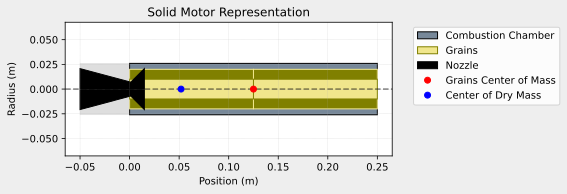

Nozzle Details
Nozzle Radius: 0.020715 m
Nozzle Throat Radius: 0.007 m

Grain Details
Number of Grains: 2
Grain Spacing: 0 m
Grain Density: 1750 kg/m3
Grain Outer Radius: 0.02 m
Grain Inner Radius: 0.01 m
Grain Height: 0.125 m
Grain Volume: 0.000 m3
Grain Mass: 0.206 kg

Motor Details
Total Burning Time: 2.131 s
Total Propellant Mass: 0.412 kg
Structural Mass Ratio: 0.638
Average Propellant Exhaust Velocity: 985.922 m/s
Average Thrust: 190.769 N
Maximum Thrust: 296.79896484 N at 0.937 s after ignition.
Total Impulse: 406.529 Ns



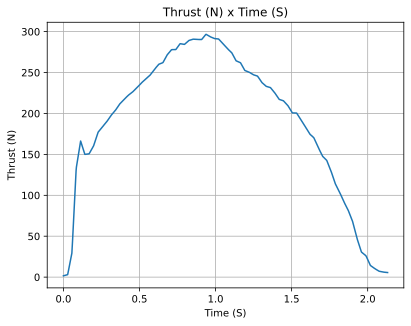

In [7]:


# Now, use the NumPy array as the thrust source to initialize SolidMotor
motor = SolidMotor(
    thrust_source=motor_data, # Use the NumPy array
    dry_mass= motor_config["dry_mass"],
    dry_inertia=motor_config["dry_inertia"],
    nozzle_radius=motor_config["nozzle_radius"],
    grain_number=motor_config["grain_number"],
    grain_density=motor_config["grain_density"],
    grain_outer_radius=motor_config["grain_outer_radius"],
    grain_initial_inner_radius=motor_config["grain_initial_inner_radius"],
    grain_initial_height=motor_config["grain_initial_height"],
    grain_separation=motor_config["grain_separation"],
    grains_center_of_mass_position=motor_config["grains_center_of_mass_position"], 
    center_of_dry_mass_position=motor_config["center_of_dry_mass_position"], 
    nozzle_position=motor_config["nozzle_position"], 
    burn_time=motor_data['Time(s)'].iloc[-1],
    throat_radius=motor_config["throat_radius"],
    coordinate_system_orientation=motor_config["coordinate_system_orientation"],
)

print("\nSolidMotor initialized successfully!")
motor.draw()
motor.info()

/home/vinicius/.local/lib/python3.14/site-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: divide by zero encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)
/home/vinicius/.local/lib/python3.14/site-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: invalid value encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)


Rocket object created successfully!


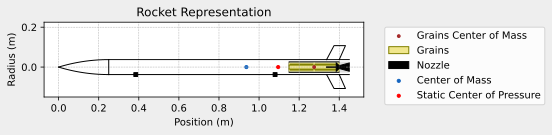

In [8]:
rocket = Rocket(
    radius = rocket_data["radius"],
    mass= rocket_data["mass"],
    power_off_drag="poweroff.csv",
    power_on_drag="poweron.csv",
    inertia= rocket_data["inertia"],
    center_of_mass_without_motor= rocket_data["center_of_mass_without_motor"],
    coordinate_system_orientation= rocket_data["coordinate_system_orientation"],
)

print("Rocket object created successfully!")
rocket.add_motor(motor, position=1.40)

nose_cone = rocket.add_nose(
    length=rocket_data["nose_length"], kind=rocket_data["nose_type"], position=rocket_data["nose_position"]
)


fins = rocket.add_trapezoidal_fins(
    n = rocket_data["n_aletas"],
    root_chord= rocket_data["root_chord"],
    tip_chord= rocket_data["tip_chord"],
    span= rocket_data["span"],
    position= rocket_data["position"],
    cant_angle= rocket_data["cant_angle"],
    sweep_length = rocket_data["sweep_length"]
)

rail_buttons = rocket.set_rail_buttons(
    upper_button_position=0.385,
    lower_button_position=1.08,
    angular_position=45,
)

rocket.draw()

In [9]:
def apogee_acc_trigger(_pressure, _height, state_vector, u_dot):
    vz = state_vector[5]
    az = u_dot[5]
    return abs(vz) < 1.0 and az < -0.1

main = rocket.add_parachute(
    name="main",
    cd_s=1.5,
    trigger=apogee_acc_trigger,
    sampling_rate=105,
    lag=1.5,
    radius=0.6,
    noise=(0, 8.3, 0.5),
)

In [10]:
rocket.info()


Inertia Details

Rocket Mass: 2.482 kg (without motor)
Rocket Dry Mass: 3.209 kg (with unloaded motor)
Rocket Loaded Mass: 3.621 kg
Rocket Structural Mass Ratio: 0.886
Rocket Inertia (with unloaded motor) 11: 0.241 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.241 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.003 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0375 m
Rocket Frontal Area: 0.004418 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.133 m
Rocket Center of Dry Mass - Nozzle Exit: 0.557 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.382 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.043 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 7.127/rad

Center of Pressure

Nose C

In [11]:
flight = Flight(
    rocket=rocket, environment=env, rail_length=4, inclination=85, heading=0
    )

In [12]:
flight.info()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 475.58 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.923 | e1: 0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 315.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.115 c


Surface Wind Conditions

Frontal Surface Wind Speed: 1.78 m/s
Lateral Surface Wind Speed: 0.75 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.468 s
Rail Departure Velocity: 16.607 m/s
Rail Departure Stability Margin: 2.213 c
Rail Departure Angle of Attack: 6.741°
Rail Departure Thrust-Weight Ratio: 6.576
Rail Departure Reynolds Number: 7.859e+04


Burn out State

Burn out time: 2.131 s
Altitude at burn out: 589.507 m (ASL) | 113.932 m (AGL)
Rocket speed at burn out: 94.498 m/s
Freestream velocity a

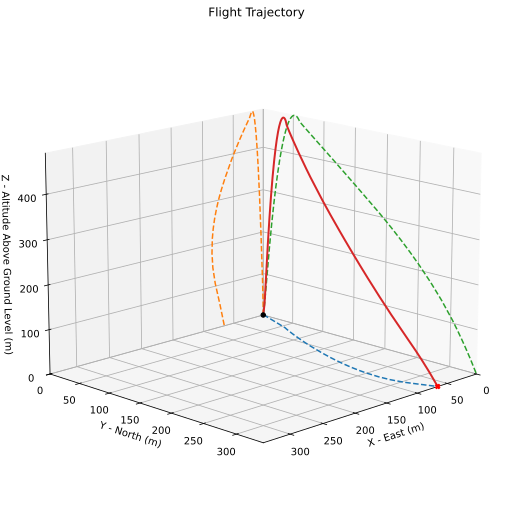

In [13]:
flight.plots.trajectory_3d()

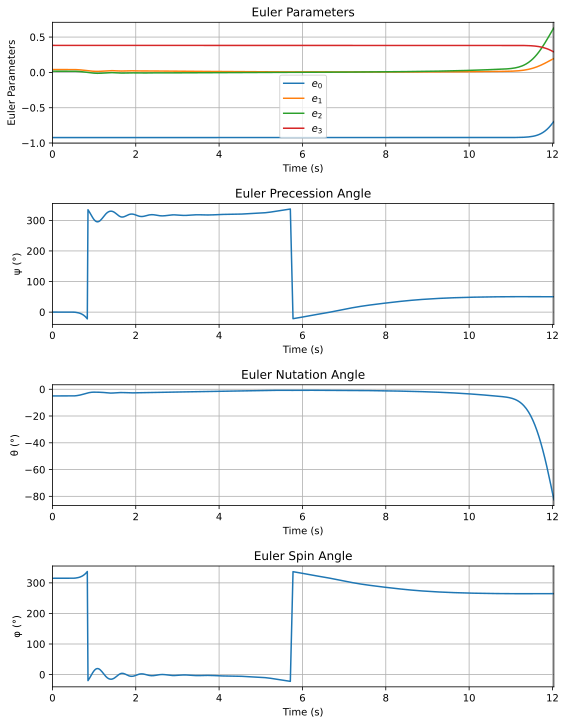

In [14]:
flight.plots.attitude_data()

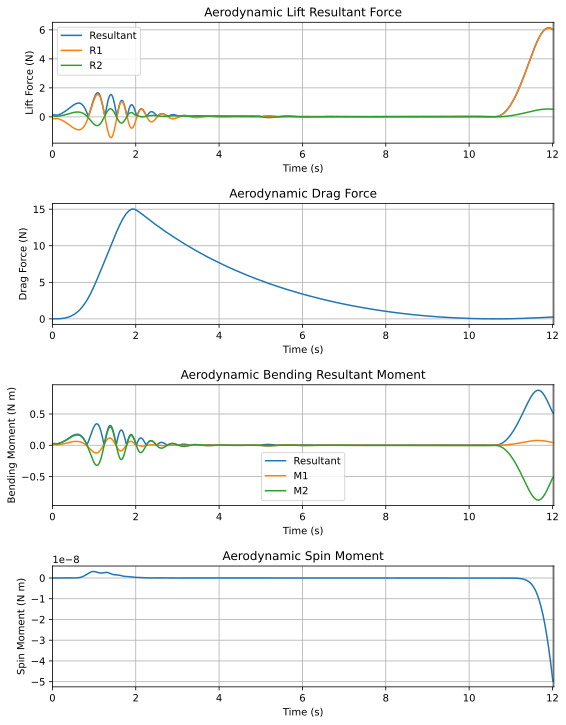

In [15]:
flight.plots.aerodynamic_forces()

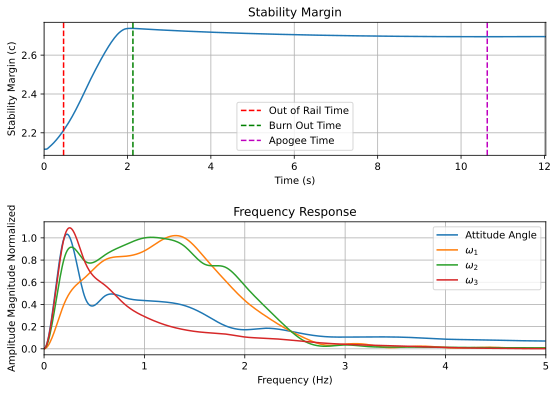

In [16]:
flight.plots.stability_and_control_data()

In [17]:
# # ═══════════════════════════════════════════════════════════════════════
# # MONTE CARLO ANALYSIS
# # ═══════════════════════════════════════════════════════════════════════

# from rocketpy import MonteCarlo
# from rocketpy.stochastic import (
#     StochasticEnvironment,
#     StochasticFlight,
#     StochasticNoseCone,
#     StochasticParachute,
#     StochasticRocket,
#     StochasticSolidMotor,
#     StochasticTrapezoidalFins,
# )

In [18]:
# # --- Stochastic Environment ---
# stochastic_env = StochasticEnvironment(
#     environment=env,
#     wind_velocity_x_factor=(1.0, 0.1),
#     wind_velocity_y_factor=(1.0, 0.1),
# )
# stochastic_env.visualize_attributes()

In [19]:
# # --- Stochastic SolidMotor ---
# stochastic_motor = StochasticSolidMotor(
#     solid_motor=motor,
#     burn_start_time=(0, 0.05, "binomial"),
#     dry_mass=0.03,
#     grain_density=50,
#     grain_initial_height=0.001,
#     grain_initial_inner_radius=0.0005,
#     grain_outer_radius=0.0005,
#     grain_separation=0.0005,
#     grains_center_of_mass_position=0.001,
#     throat_radius=0.0003,
#     nozzle_radius=0.0003,
#     nozzle_position=0.001,
# )
# stochastic_motor.visualize_attributes()

In [20]:
# # --- Stochastic Rocket ---
# stochastic_rocket = StochasticRocket(
#     rocket=rocket,
#     radius=0.001,
#     mass=(2.482, 0.1, "normal"),
#     inertia_11=0.005,
#     inertia_22=0.005,
#     inertia_33=0.001,
#     center_of_mass_without_motor=0.005,
#     power_off_drag_factor=(1.0, 0.05),
#     power_on_drag_factor=(1.0, 0.05),
# )
# stochastic_rocket.visualize_attributes()

# # --- Stochastic Nose Cone ---
# stochastic_nose = StochasticNoseCone(
#     nosecone=nose_cone,
#     length=0.001,
# )

# # --- Stochastic Fins ---
# stochastic_fins = StochasticTrapezoidalFins(
#     trapezoidal_fins=fins,
#     root_chord=0.001,
#     tip_chord=0.001,
#     span=0.001,
# )

# # --- Stochastic Parachute ---
# stochastic_parachute = StochasticParachute(
#     parachute=main,
#     cd_s=0.1,
#     lag=0.2,
# )

# # Add components
# stochastic_rocket.add_motor(stochastic_motor, position=0.001)
# stochastic_rocket.add_nose(stochastic_nose, position=(0.001, "normal"))
# stochastic_rocket.add_trapezoidal_fins(stochastic_fins, position=(0.001, "normal"))
# stochastic_rocket.add_parachute(stochastic_parachute)

In [21]:
# # --- Stochastic Flight ---
# stochastic_flight = StochasticFlight(
#     flight=flight,
#     inclination=(85, 1),
#     heading=(0, 2),
# )
# stochastic_flight.visualize_attributes()

In [22]:
# mc_thonyan = MonteCarlo(
#     filename="monte_carlo_thonyan_output",
#     environment=stochastic_env,
#     rocket=stochastic_rocket,
#     flight=stochastic_flight,
# )
# mc_thonyan.simulate(
#      number_of_simulations=100,
#     append=False,
#     include_function_data=False,
#     parallel=True,
#     n_workers=4,
# )

In [23]:
# mc_thonyan.prints.all()

In [37]:
# # Elipses de dispersao do ponto de impacto
# # mc_thonyan.plots.ellipses()
# mc_thonyan.plots.ellipses(background="satellite")

In [24]:
# # # Todos os graficos de dispersao
# mc_thonyan.plots.all()

In [25]:
# Exportar elipses para KML (Google Earth)
# mc_thonyan.export_ellipses_to_kml(
#     filename="monte_carlo_thonyan_ellipses.kml",
#     origin_lat=env.latitude,
#     origin_lon=env.longitude,
#     type="impact",
# )